In [2]:
# Advanced Task 2: Customer Segmentation using Unsupervised Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [13]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
display(df.head())

print("\nDataset Info:")
print(df.info())


Dataset Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [17]:
# 1️⃣ Load dataset
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")  

# 2️⃣ Check original columns and missing values
print("Original Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

# 3️⃣ Rename columns if needed (match exactly number of columns)
df.columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

# 4️⃣ Encode Gender as numeric for modeling if needed
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# ✅ Dataset ready
print("\nDataset Head:\n", df.head())


Original Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Dataset Head:
    CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1       0   19            15             39
1           2       0   21            15             81
2           3       1   20            16              6
3           4       1   23            16             77
4           5       1   31            17             40


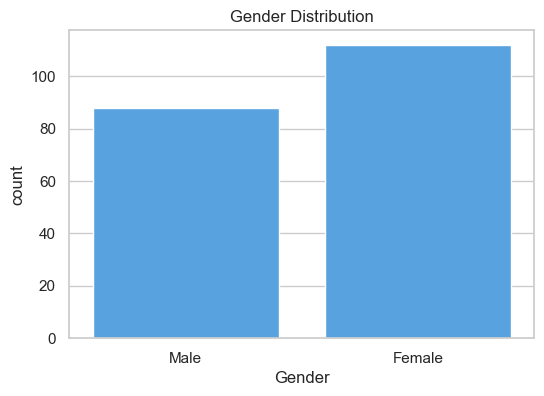

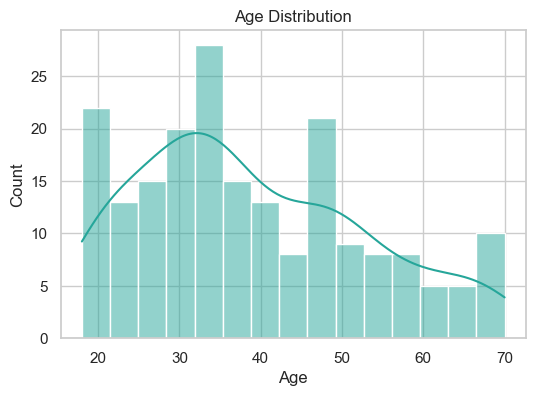

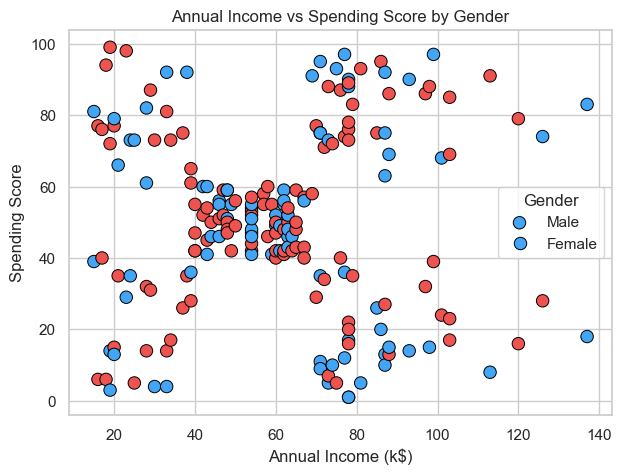

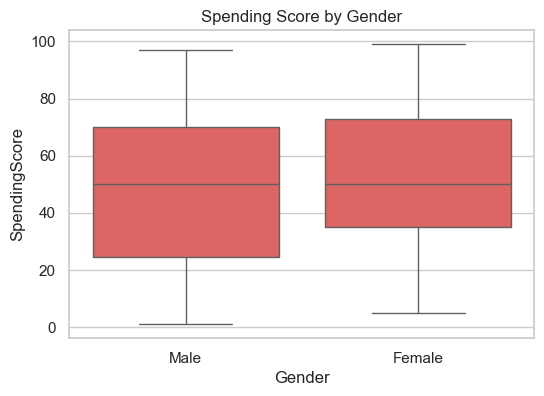

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1️⃣ Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", color="#42a5f5")  # Use 'color' instead of 'palette'
plt.xticks(ticks=[0,1], labels=["Male", "Female"])
plt.title("Gender Distribution")
plt.show()

# 2️⃣ Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=15, kde=True, color="#26a69a")
plt.title("Age Distribution")
plt.show()

# 3️⃣ Annual Income vs Spending Score (scatter)
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore", hue="Gender", palette=["#42a5f5", "#ef5350"], s=80, edgecolor="black")
plt.title("Annual Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend(title="Gender", labels=["Male", "Female"])
plt.show()

# 4️⃣ Boxplot: Spending Score by Gender
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Gender", y="SpendingScore", color="#ef5350")  # Use 'color' instead of 'palette'
plt.xticks(ticks=[0,1], labels=["Male", "Female"])
plt.title("Spending Score by Gender")
plt.show()


In [23]:
# Select relevant features for clustering
X = df[['Age', 'AnnualIncome', 'SpendingScore']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled successfully")


✅ Features scaled successfully


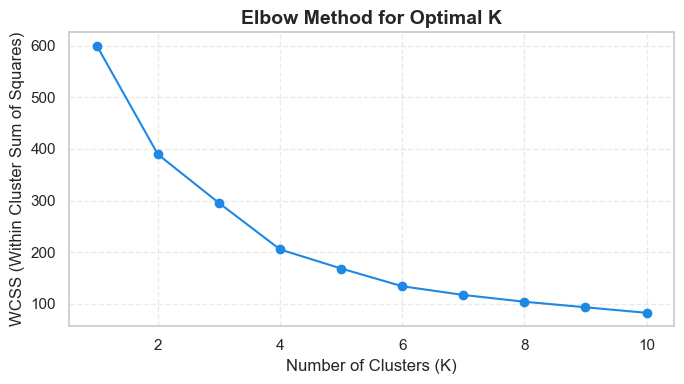

In [25]:
import warnings
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Suppress specific KMeans memory leak warning
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 11), wcss, marker='o', color="#1e88e5")
plt.title("Elbow Method for Optimal K", fontsize=14, weight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within Cluster Sum of Squares)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [27]:

import os
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1️⃣ Suppress KMeans memory-leak warnings on Windows
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

# 2️⃣ Standardize features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['AnnualIncome', 'SpendingScore']])

# 3️⃣ Apply KMeans with optimal K (assume K=5 from elbow method)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering applied successfully with K={k}")
df.head()


K-Means clustering applied successfully with K=5


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4


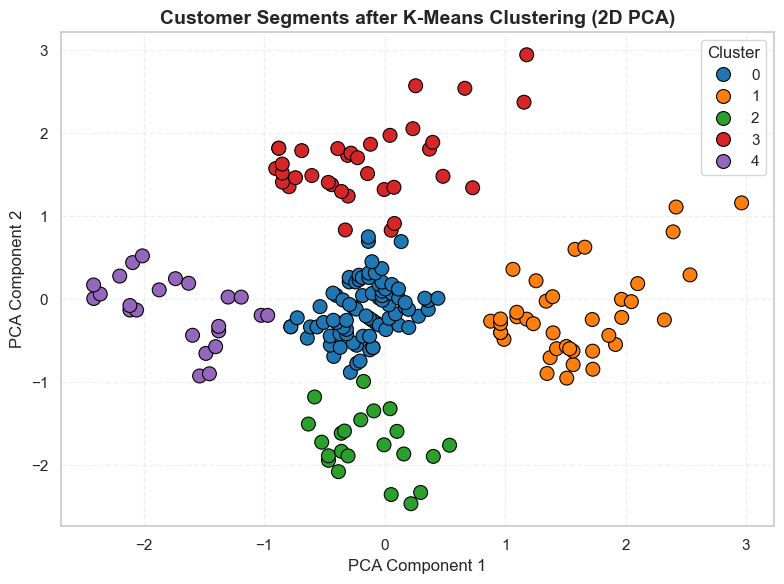

In [29]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# 1️⃣ Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# 2️⃣ Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='tab10',
    data=df,
    s=100,
    edgecolor='black'
)
plt.title("Customer Segments after K-Means Clustering (2D PCA)", fontsize=14, weight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Cluster Sizes:
 Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Characteristics (Mean Values):
           Age  AnnualIncome  SpendingScore
Cluster                                   
0        42.7          55.3           49.5
1        32.7          86.5           82.1
2        25.3          25.7           79.4
3        41.1          88.2           17.1
4        45.2          26.3           20.9


<Figure size 800x500 with 0 Axes>

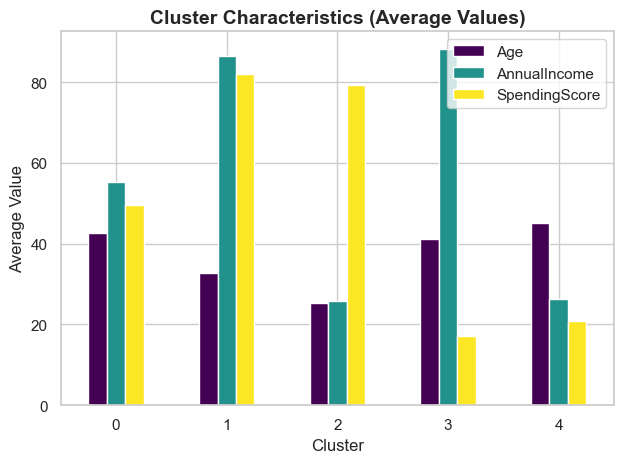

In [31]:


cluster_summary = df.groupby('Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(1)
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Cluster Sizes:\n", cluster_counts)
print("\nCluster Characteristics (Mean Values):\n", cluster_summary)

# Optional: visualize cluster statistics
plt.figure(figsize=(8,5))
cluster_summary.plot(kind='bar', colormap='viridis')
plt.title("Cluster Characteristics (Average Values)", fontsize=14, weight='bold')
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [32]:

# Example insights based on cluster characteristics
for cluster in cluster_summary.index:
    size = cluster_counts[cluster]
    income = cluster_summary.loc[cluster, 'AnnualIncome']
    score = cluster_summary.loc[cluster, 'SpendingScore']
    
    print(f"Cluster {cluster}: {size} customers")
    print(f"  - Average Annual Income: ${income}k")
    print(f"  - Average Spending Score: {score}")
    
    if income > df['AnnualIncome'].mean() and score > df['SpendingScore'].mean():
        print("  -> Target for premium marketing campaigns.\n")
    elif income < df['AnnualIncome'].mean() and score > df['SpendingScore'].mean():
        print("  -> Target for value deals and loyalty programs.\n")
    else:
        print("  -> Standard marketing approach recommended.\n")

print("✅ Marketing insights generated successfully.")


Cluster 0: 81 customers
  - Average Annual Income: $55.3k
  - Average Spending Score: 49.5
  -> Standard marketing approach recommended.

Cluster 1: 39 customers
  - Average Annual Income: $86.5k
  - Average Spending Score: 82.1
  -> Target for premium marketing campaigns.

Cluster 2: 22 customers
  - Average Annual Income: $25.7k
  - Average Spending Score: 79.4
  -> Target for value deals and loyalty programs.

Cluster 3: 35 customers
  - Average Annual Income: $88.2k
  - Average Spending Score: 17.1
  -> Standard marketing approach recommended.

Cluster 4: 23 customers
  - Average Annual Income: $26.3k
  - Average Spending Score: 20.9
  -> Standard marketing approach recommended.

✅ Marketing insights generated successfully.
